In [8]:
#Load packages
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import json
import csv

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])

In [2]:
#TMRCA statistics

TMRCA = []

with open("/Users/ricardorivero/Documents/DENV/2024/D2/Logs/subsampled_D2lin_combined.log","r") as f:
    reader = csv.DictReader(f, delimiter="\t")
    print(reader.fieldnames)
    for row in reader:
        mrca = float(row['age(root)'])
        TMRCA.append(mrca)

TMRCA_data = pd.DataFrame(TMRCA,columns=['TMRCA'])
print(TMRCA_data)

['state', 'joint', 'prior', 'likelihood', 'treeModel.rootHeight', 'age(root)', 'treeLength', 'skyline.popSize1', 'skyline.popSize2', 'skyline.popSize3', 'skyline.popSize4', 'skyline.popSize5', 'skyline.popSize6', 'skyline.popSize7', 'skyline.popSize8', 'skyline.popSize9', 'skyline.popSize10', 'skyline.groupSize1', 'skyline.groupSize2', 'skyline.groupSize3', 'skyline.groupSize4', 'skyline.groupSize5', 'skyline.groupSize6', 'skyline.groupSize7', 'skyline.groupSize8', 'skyline.groupSize9', 'skyline.groupSize10', 'gtr.rates.rateAC', 'gtr.rates.rateAG', 'gtr.rates.rateAT', 'gtr.rates.rateCG', 'gtr.rates.rateCT', 'gtr.rates.rateGT', 'frequencies1', 'frequencies2', 'frequencies3', 'frequencies4', 'alpha', 'ucld.mean', 'ucld.stdev', 'meanRate', 'coefficientOfVariation', 'covariance', 'treeLikelihood', 'branchRates', 'skyline']
              TMRCA
0       2005.975896
1       2005.968202
2       2005.761301
3       2005.883334
4       2005.142489
...             ...
239998  2005.407734
239999  2

AttributeError: 'Series' object has no attribute 'reshape'

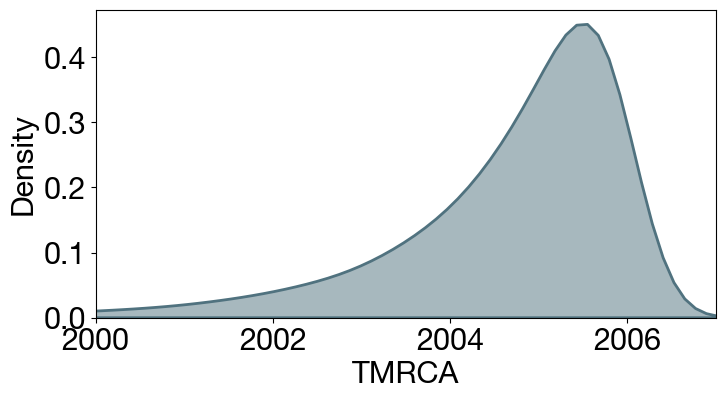

In [92]:
#Plot density plot with seaborn
#compute density
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.stats import norm

from sklearn.neighbors import KernelDensity

X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]


# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 4), facecolor='w', frameon=False)

# Plot the data
sns.kdeplot(ax, x=TMRCA_data['TMRCA'], color='#50727F', linewidth=2, fill=True, alpha=0.5, bw_adjust=3)
ax.set_xlim(2000, 2007)

kde = KernelDensity(kernel="gaussian", bandwidth=0.75).fit(TMRCA_data['TMRCA'].reshape(-1, 1))
log_dens = kde.score_samples(X_plot)
ax[1, 1].fill(X_plot[:, 0], np.exp(log_dens), fc="#AAAAFF")
ax[1, 1].text(-3.5, 0.31, "Gaussian Kernel Density")


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns

In [49]:
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/D2_lineage_combined.mcc.tre'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

focal_node=ll.commonAncestor([k for k in ll.getExternal(lambda w: w.is_leaf())])

print(focal_node.y)

124.4416424036026


2004.5382488812493
['Ecuador', 'USA', 'Venezuela', 'Colombia']


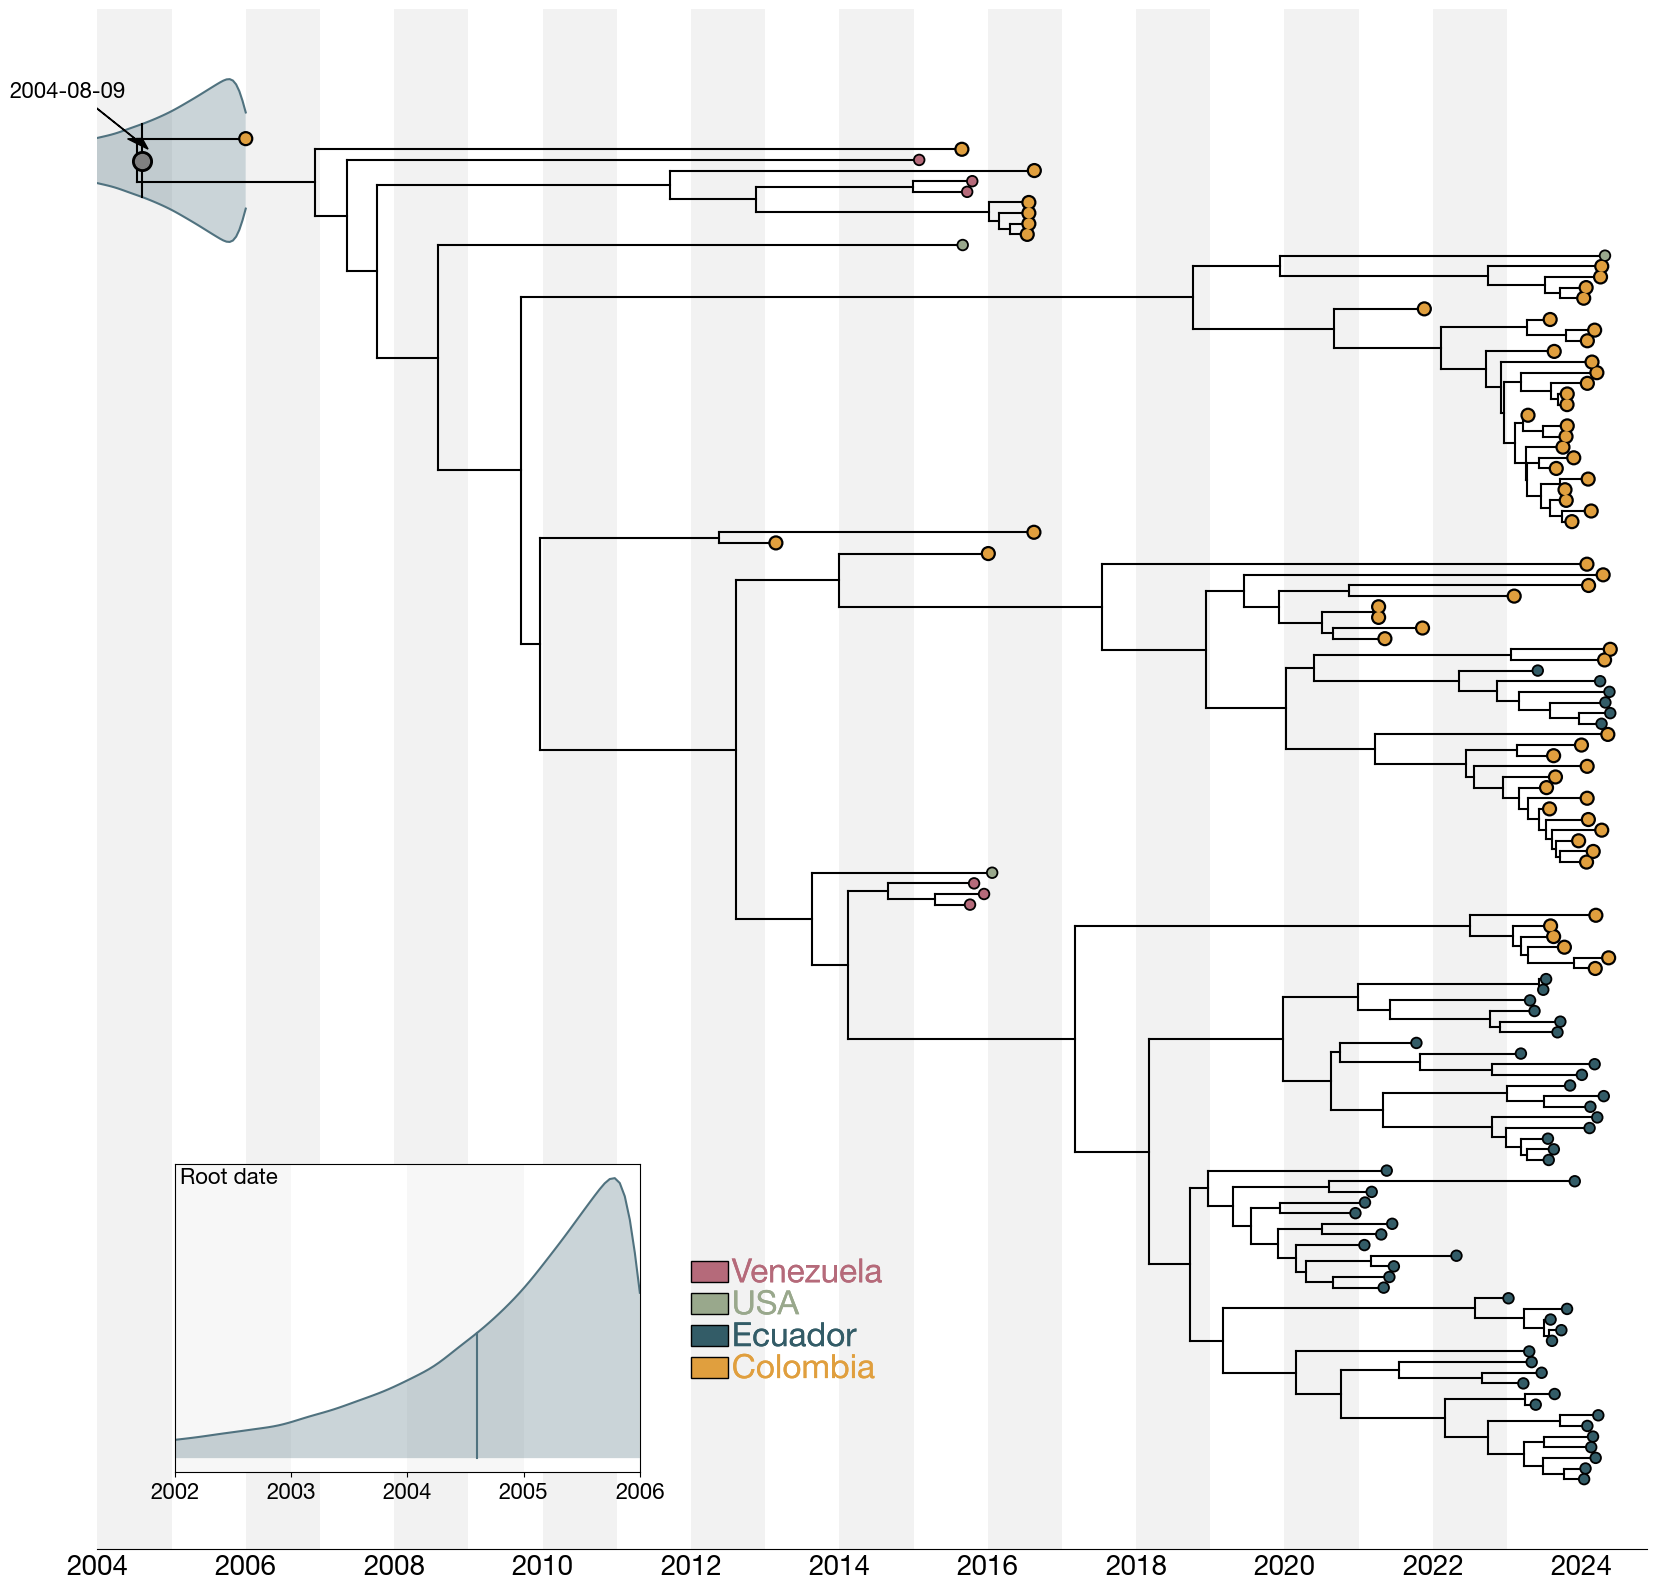

In [172]:
import matplotlib.patches as mpatches
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/D2_lineage_combined.mcc.tre'

ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)
focal_node=ll.commonAncestor([k for k in ll.getExternal(lambda w: w.is_leaf())])
x_attr = lambda k: k.absoluteTime

colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#B56A7A', 'Colombia':'#e09f3e'}


for k in ll.Objects:
    if k.is_leaf():
        k.traits['location'] = k.name.split('/')[1]
        if k.traits['location'] == 'mosquito':
            k.traits['location'] = k.name.split('/')[2]


earliest_node = 100000000
for k in ll.Objects:
    if k.absoluteTime < earliest_node:
        earliest_node = k.absoluteTime

print(earliest_node)

root_y = 0
for k in ll.Objects:
    if k.absoluteTime == earliest_node:
        root_y = k.y

c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 40

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour='k', width=1.5)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

ax.text(2004.606-1, 124+6, '2004-08-09', fontsize=16, ha='center', va='bottom', color='k')
plt.arrow(2004.606-1, 124+7.5, 0.9, -5, 
          head_width = 0.2,
          head_length = 1,
          width = 0.01,
          ec ='k',
          fc = 'k', zorder = 1000)

data = TMRCA_data['TMRCA']
kde=gaussian_kde(data)
hpdLo,hpdHi=hpd(data,0.95)
x_grid=np.linspace(hpdLo,hpdHi,100)
scale=13
if focal_node.y is not None:
    y_up = [focal_node.y + y * scale for y in kde(x_grid)]
else:
    y_up = []
if focal_node.y is not None:
    y_lo=[focal_node.y - y * scale for y in kde(x_grid)]
else: 
    y_lo = []

ax.plot(x_grid,y_lo,color='#50727F') ## plot TMRCA 95% HPD
ax.plot(x_grid,y_up,color='#50727F')
ax.fill_between(x_grid,y_lo,y_up,facecolor='#50727F',alpha=0.3)
    
mu=np.mean(data) ## indicate mean
ax.plot([mu,mu],[focal_node.y+kde(mu)*scale,focal_node.y-kde(mu)*scale],ls='-',color='k')
ax.scatter(mu,focal_node.y,s=100,facecolor='grey',zorder=3)
ax.scatter(mu,focal_node.y,s=200,facecolor='k',zorder=2)
    
mostRecent=max(ll.getParameter('absoluteTime'))

years = np.arange(2004, 2025, 2)

axins = ax.inset_axes([0.05, 0.05, 0.3, 0.2]) ## inset axes for root TMRCA
    
node=ll.root
data=TMRCA_data['TMRCA'] ## get root TMRCA posterior
#annotate the date of the root
    
kde=gaussian_kde(data)
hpdLo,hpdHi=hpd(data,0.95)
x_grid=np.linspace(hpdLo,hpdHi,100)
y_grid=kde(x_grid)
    
    
axins.plot(x_grid,y_grid,color='#50727F') ## plot root TMRCA
axins.fill_between(x_grid,y_grid,facecolor='#50727F',alpha=0.3)
mu=np.mean(data)
mu_density = kde(mu)[0]
axins.plot([mu,mu],[0,mu_density],color='#50727F')
    

[axins.axvspan(t,t+1,facecolor='k',edgecolor='none',alpha=0.03,zorder=0) for t in range(2002,2006,1) if t % 2 == 0] 
    
axins.set_yticks([])
axins.set_yticklabels([])
axins.tick_params(labelsize=16)
axins.text(0.01,0.99,'Root date',size=16,va='top',ha='left',transform=axins.transAxes)
    
axins.set_xlim(2002,2006)


country_list = list(colors.keys())
print(country_list)

h=2
w=0.5

for c,C in enumerate(sorted(country_list)): ## add legend
    fc=colors[C] if C in colors else 'grey'
    effects=[path_effects.Stroke(linewidth=7, foreground='none'),
                        path_effects.Stroke(linewidth=0.0, foreground=fc)]
    ax.add_patch(Rectangle((2012,10+c*3),w,h,facecolor=fc,edgecolor='k',clip_on=False))
    ax.text(2012+w*1.1,10+c*3,C,size=24,color=fc,path_effects=effects)


# Set the x-ticks and labels to be the years array
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']] ## remove all figure spines except bottom

ax.tick_params(axis='x',size=0,labelsize=20) ## no x axis ticks or labels
ax.tick_params(axis='y',size=0,labelsize=0) ## no y axis ticks or labels
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x,x+1,fc='k',ec='none',alpha=0.05,zorder=0) for x in range(2004,2024,1) if x%2==0]

ax.set_xlim(2004,ll.mostRecent+0.5)


resolutionValue = 1200
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/TMRCA_D2.jpeg', dpi=resolutionValue, bbox_inches='tight')
plt.show()

2004.5382488812493


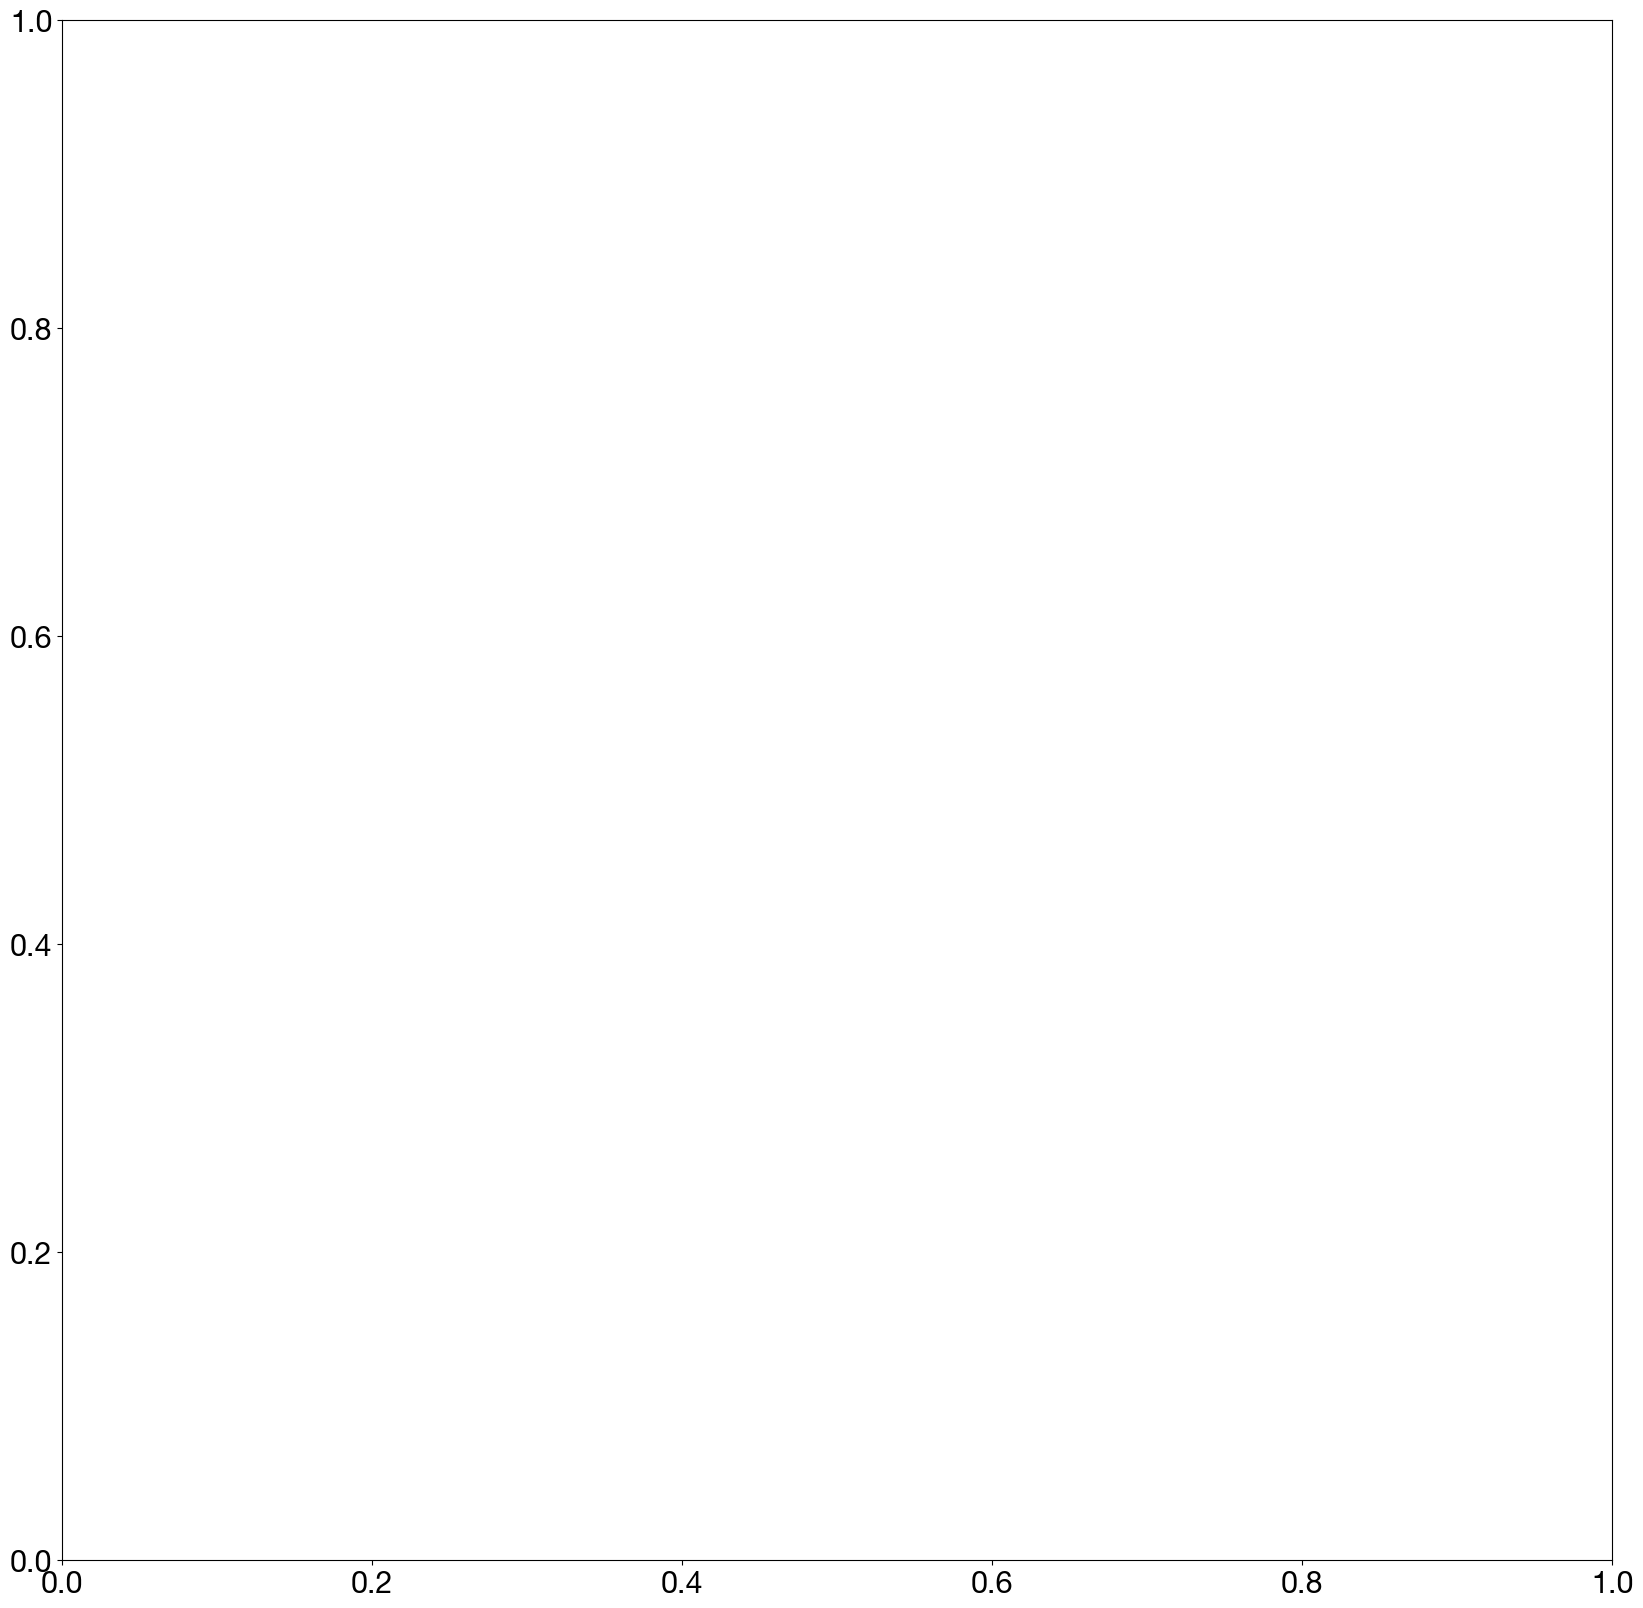

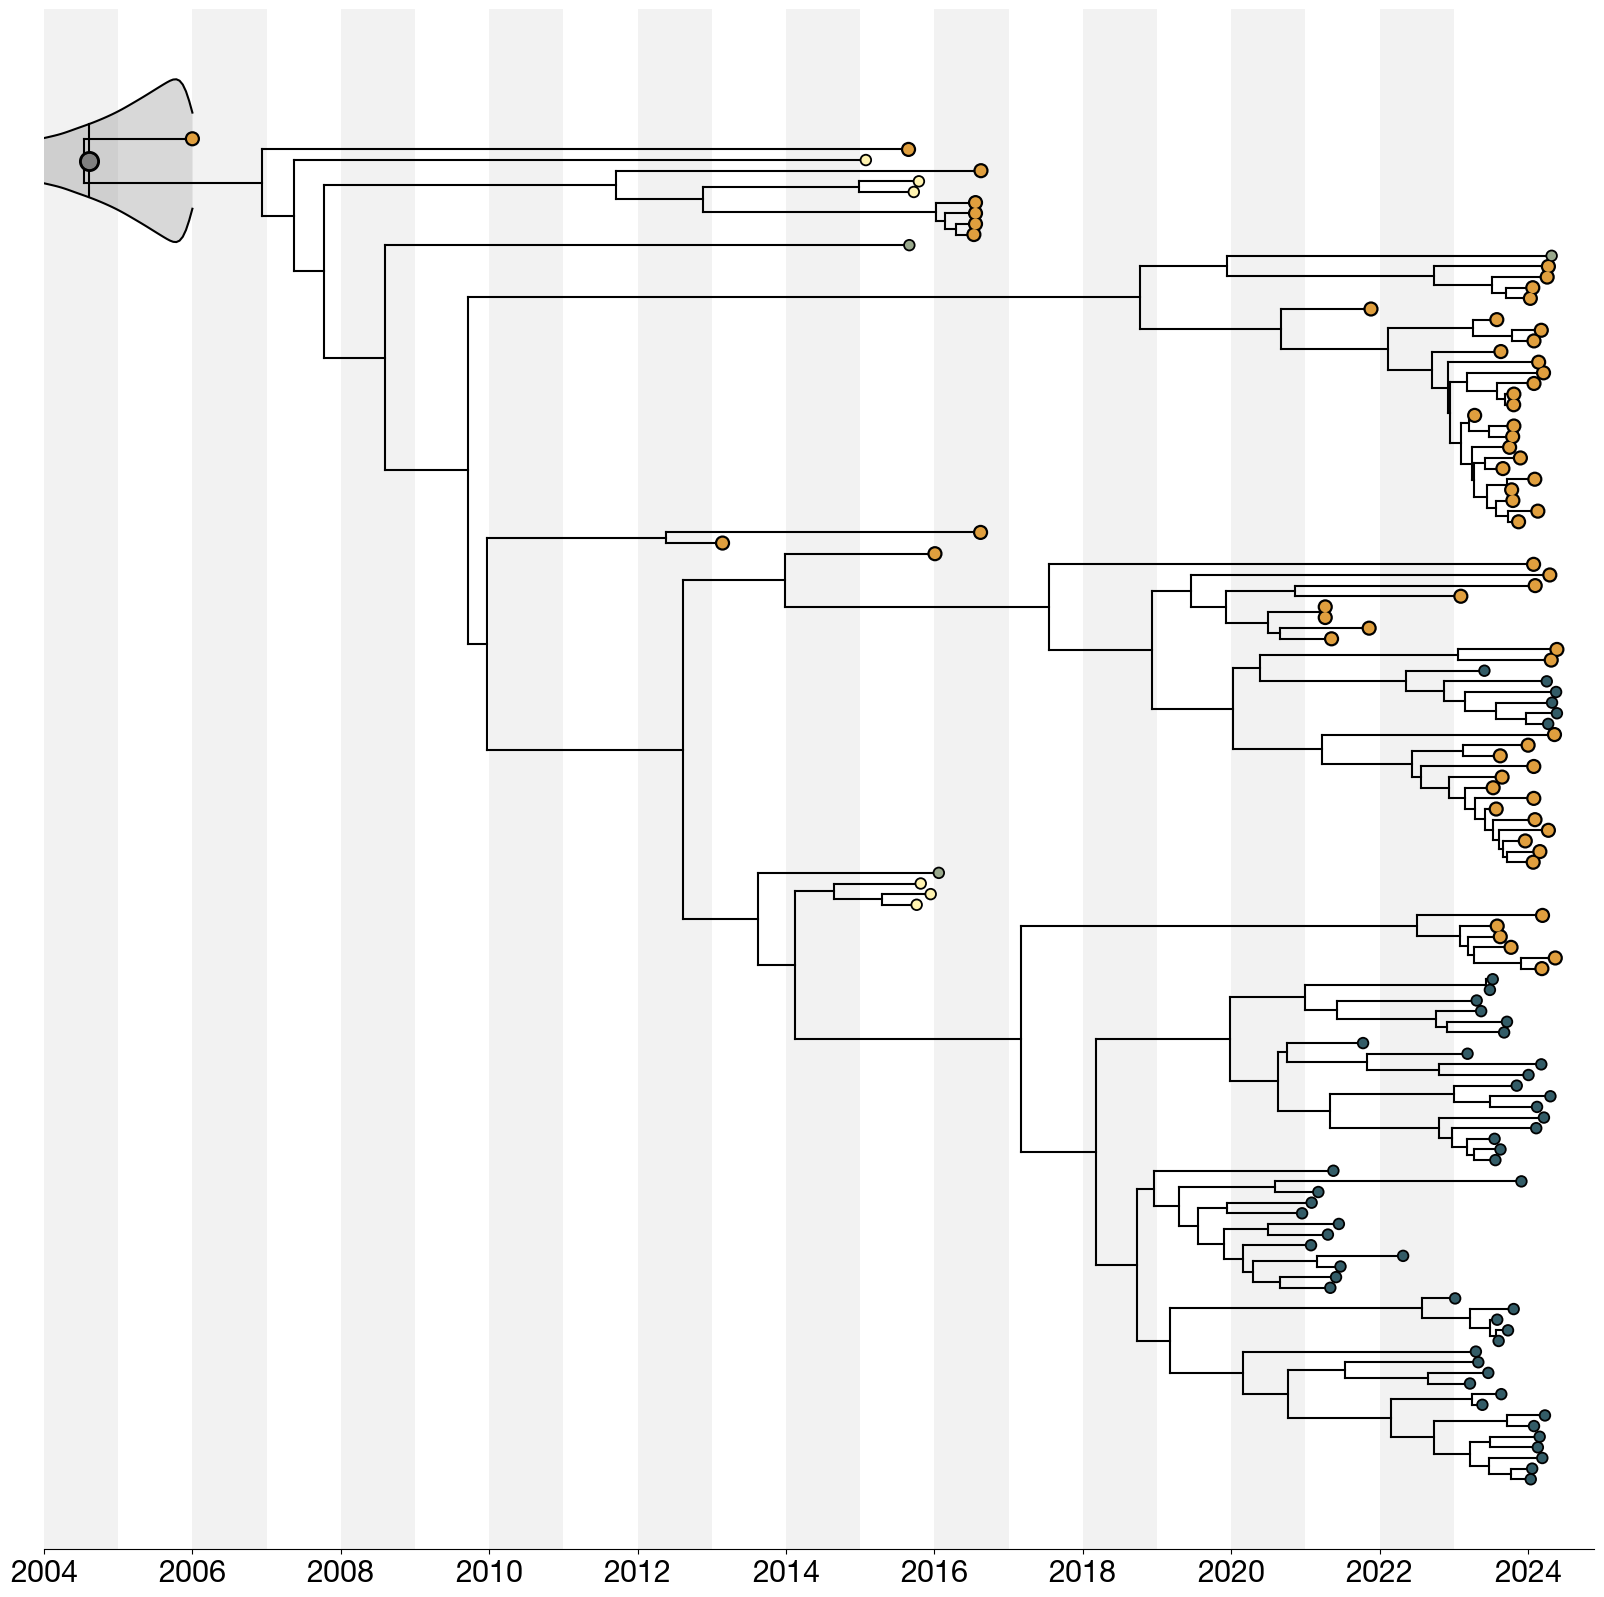

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Assuming you have already loaded the tree and data
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/Trees/D2_lineage_combined.mcc.tre'
ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

# Other parts of your plotting logic, setting up the tree, colors, etc.

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')


x_attr = lambda k: k.absoluteTime

colors = {'Ecuador':'#335c67', 'USA': '#99a88c', 'Venezuela': '#fff3b0', 'Colombia':'#e09f3e'}

focal_node=ll.commonAncestor([k for k in ll.getExternal(lambda w: w.is_leaf())])


for k in ll.Objects:
    if k.is_leaf():
        k.traits['location'] = k.name.split('/')[1]
        if k.traits['location'] == 'mosquito':
            k.traits['location'] = k.name.split('/')[2]


earliest_node = 100000000
for k in ll.Objects:
    if k.absoluteTime < earliest_node:
        earliest_node = k.absoluteTime

print(earliest_node)

root_y = 0
for k in ll.Objects:
    if k.absoluteTime == earliest_node:
        #plt.hlines(k.y,0,k.absoluteTime,color="black")
        root_y = k.y

c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 40

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour='k', width=1.5)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

# Plot TMRCA density estimate
data = TMRCA_data['TMRCA']
kde = gaussian_kde(data)
hpdLo, hpdHi = hpd(data, 0.95)
x_grid = np.linspace(hpdLo, hpdHi, 100)
scale = 13
y_up = [focal_node.y + y * scale for y in kde(x_grid)]
y_lo = [focal_node.y - y * scale for y in kde(x_grid)]

# Plot HPD interval
ax.plot(x_grid, y_lo, color='k')
ax.plot(x_grid, y_up, color='k')
ax.fill_between(x_grid, y_lo, y_up, facecolor='grey', alpha=0.3)

# Plot mean of the data
mu = np.mean(data)
ax.plot([mu, mu], [focal_node.y + kde(mu) * scale, focal_node.y - kde(mu) * scale], ls='-', color='k')
ax.scatter(mu, focal_node.y, s=100, facecolor='grey', zorder=3)
ax.scatter(mu, focal_node.y, s=200, facecolor='k', zorder=2)

# Get the most recent date from the tree
mostRecent = max(ll.getParameter('absoluteTime'))

# Set x-ticks explicitly and remove decimals
years = np.arange(2004, 2025, 2)
plt.xticks(years, labels=[str(int(year)) for year in years])

# Adjust the x-axis limits
ax.set_xlim(2004, mostRecent + 0.5)

# Remove extra spines and y-ticks
ax.set_yticks([])
ax.set_yticklabels([])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]

# Optional: vertical grid lines at even years
[ax.axvspan(x, x + 1, fc='k', ec='none', alpha=0.05, zorder=0) for x in range(2004, 2024, 1) if x % 2 == 0]

# Finally show the plot
plt.show()